# 06 — Neural Two-Tower

## Why this matters

ALS is restricted to exactly the dot-product-of-learned-factors form, fit by a closed-form
alternating solve. A neural two-tower model learns the same kind of user/item vectors, but by
gradient descent on sampled examples — which is strictly more flexible (either tower can
later ingest more than an id: text embeddings, audio features, metadata) at the cost of a
much less constrained, non-convex optimization. With no side features yet (just user and item
ids), the fair question is whether that flexibility is already paying for itself, or whether
it's pure overhead until there's a feature to plug into a tower.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import viz
from groovn.data import build_interaction_matrix, load_filtered_split
from groovn.evaluation import build_ground_truth, warm_user_rows
from groovn.metrics import evaluate_rankings
from groovn.ranking import top_k_excluding_seen
from groovn.two_tower import model_scores, pick_device, train_two_tower

viz.style()
RANDOM_STATE = 42
K = 10

train, test, cutoff = load_filtered_split()
matrix, user_index, item_index = build_interaction_matrix(train, value_col="rating")
warm_rows = warm_user_rows(test, user_index)
ground_truth = build_ground_truth(test, user_index, item_index)
n_items = matrix.shape[1]
device = pick_device()
print("training device:", device)

training device: mps


## The model: two embedding towers, trained with negative sampling

Each tower is an embedding table: `user_tower[u]` and `item_tower[i]` are learned vectors,
and the predicted affinity is their dot product — architecturally identical to what ALS
produces, just fit differently. There's no labeled "negative" in implicit feedback (we only
observe interactions that happened), so **negative sampling** manufactures them: for every
real `(user, item)` interaction, pair that user with a handful of items drawn uniformly at
random, label the real pair `1` and the random pairs `0`, and train with binary
cross-entropy. At this catalog's density (~0.014% filled), a uniformly sampled "negative" is
a true positive only by rare chance — accepted as label noise rather than something worth the
extra bookkeeping to filter out.

## Training

10 epochs, 64 factors (matching ALS's factor count for a fair comparison), 4 negatives per
positive, Adam at `lr=0.01`, on whichever device PyTorch reports (`mps` on this M3).

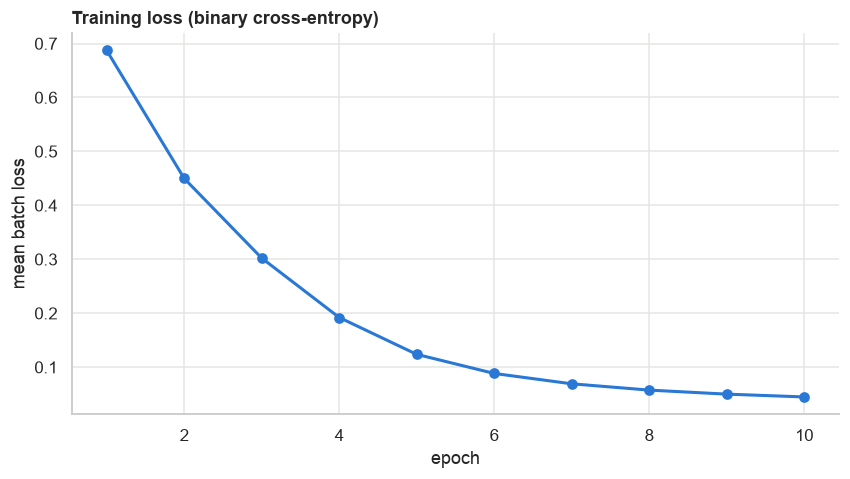

[0.6873, 0.4499, 0.3023, 0.1921, 0.1238, 0.0883, 0.0691, 0.0575, 0.05, 0.0448]


In [2]:
model, losses = train_two_tower(
    matrix, n_factors=64, epochs=10, batch_size=8192, n_negatives=4,
    lr=0.01, random_state=RANDOM_STATE, device=device,
)

ax = viz.new_ax()
ax.plot(range(1, len(losses) + 1), losses, marker="o", color=viz.BLUE)
viz.label(ax, "Training loss (binary cross-entropy)", "epoch", "mean batch loss")
plt.show()
print([round(l, 4) for l in losses])

**Reading the result:** loss drops smoothly from ~0.69 (the BCE loss of a coin flip) to
~0.045 — the model is clearly learning *something* and optimization is well-behaved (no
divergence, no instability). Whether that something is useful for ranking is a separate
question, answered next.

In [3]:
scores_fn = model_scores(model, device)
top_k = top_k_excluding_seen(scores_fn, matrix, warm_rows, K, batch_size=1000)
rankings = {u: list(row[row >= 0]) for u, row in zip(warm_rows, top_k)}
two_tower_metrics = evaluate_rankings(rankings, ground_truth, K, n_items)
two_tower_metrics

{'recall@10': 0.005053220188993578,
 'ndcg@10': 0.0038870767944144545,
 'coverage@10': 0.23828923032288482,
 'n_users_evaluated': 32384}

**Reading the result:** recall@10 ≈ 0.005 and NDCG@10 ≈ 0.004 — *lower* than both ALS
variants from notebook 5 (0.010-0.014) and well below item-kNN (0.0156), despite the loss
curve looking perfectly healthy. Coverage@10 ≈ 24% sits between ALS's ~2-6% and kNN's ~79%.

**Why a clean loss curve doesn't guarantee good ranking:** BCE with uniform random negatives
asks the model to separate "did this exact interaction happen" from "did this random pair
happen" — and because almost every random pair is a true negative, the model can drive loss
down just by learning coarse structure (e.g., which items are popular enough to show up as
positives at all) without learning the finer-grained *relative* ordering between two items a
specific user might both plausibly like. Training loss measures the proxy task; Recall/NDCG
measure the actual task — this is exactly the gap notebook 3's harness exists to catch, and
exactly why "the loss went down" is never treated as sufficient evidence of a good
recommender in this project.

## Full comparison so far

/Users/lucasavila/Documents/python/groovn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:00<00:13,  1.02it/s]

 13%|█▎        | 2/15 [00:01<00:12,  1.02it/s]

 20%|██        | 3/15 [00:02<00:11,  1.03it/s]

...

 80%|████████  | 12/15 [00:11<00:02,  1.04it/s]

 87%|████████▋ | 13/15 [00:12<00:01,  1.04it/s]

 93%|█████████▎| 14/15 [00:13<00:00,  1.04it/s]

100%|██████████| 15/15 [00:14<00:00,  1.04it/s]

100%|██████████| 15/15 [00:14<00:00,  1.04it/s]

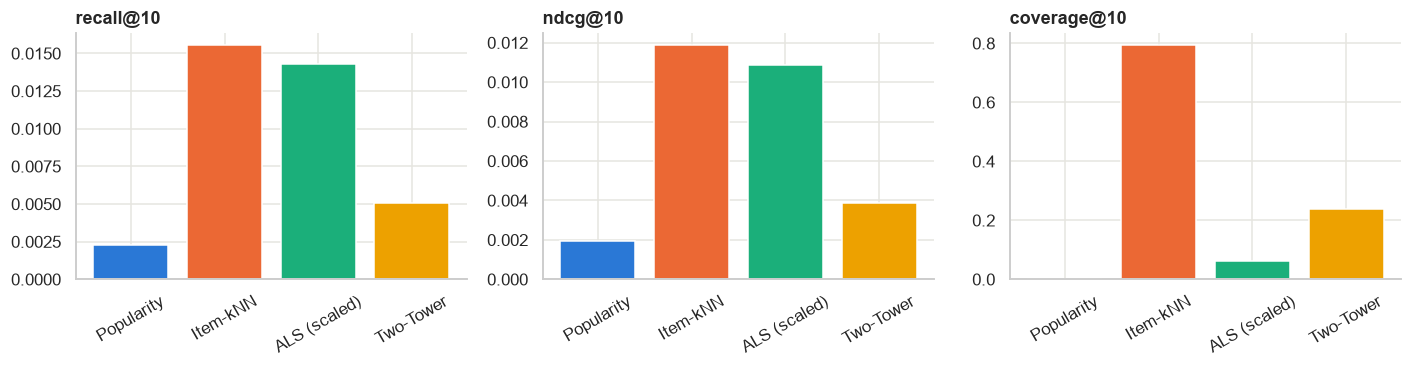

In [4]:
from groovn.baselines import ItemKNNRecommender, PopularityRecommender
from groovn.mf import ALSRecommender

pop_metrics = evaluate_rankings(
    {u: list(r[r >= 0]) for u, r in zip(warm_rows, top_k_excluding_seen(PopularityRecommender().fit(matrix).scores(), matrix, warm_rows, K))},
    ground_truth, K, n_items,
)
knn_metrics = evaluate_rankings(
    {u: list(r[r >= 0]) for u, r in zip(warm_rows, top_k_excluding_seen(ItemKNNRecommender(n_neighbors=50).fit(matrix).scores(), matrix, warm_rows, K, batch_size=2000))},
    ground_truth, K, n_items,
)
scaled_confidence = matrix.copy()
scaled_confidence.data = 1.0 + 10.0 * scaled_confidence.data
als_metrics = evaluate_rankings(
    {u: list(r[r >= 0]) for u, r in zip(warm_rows, top_k_excluding_seen(ALSRecommender(factors=64, iterations=15, random_state=RANDOM_STATE).fit(scaled_confidence).scores(), matrix, warm_rows, K, batch_size=1000))},
    ground_truth, K, n_items,
)

results = {"Popularity": pop_metrics, "Item-kNN": knn_metrics, "ALS (scaled)": als_metrics, "Two-Tower": two_tower_metrics}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, metric in zip(axes, [f"recall@{K}", f"ndcg@{K}", f"coverage@{K}"]):
    ax.bar(list(results), [results[name][metric] for name in results], color=viz.CATEGORICAL[:4])
    viz.label(ax, metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Takeaways

- The two-tower model trains cleanly and is architecturally sound, but on *this* task, with
  *no content features* and uniform random negative sampling, it doesn't beat ALS or
  item-kNN — a legitimate result, and the point of having a fixed harness is to surface
  exactly this instead of a hand-wavy "the neural one is probably better."
- Its real selling point was never going to show up here: a two-tower architecture earns its
  complexity once a tower consumes more than an id — review text embeddings, audio features,
  genre/metadata — none of which exist in this dataset yet. Building that out is future work,
  not a gap in this notebook (YAGNI: no feature to feed it yet).
- Item-kNN remains the strongest model across every notebook so far. Notebook 7 checks whether
  that holds up once segmented by cold users and long-tail items, rather than taking the
  overall average as the final word.